# Import libraries

In [1]:
!pip install -q py_vncorenlp seqeval torchinfo

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.7 MB/s eta 0:00:00


In [2]:
import os
import random
import unicodedata

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

import py_vncorenlp
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification
)

from seqeval.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42

def set_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

# Download dataset

In [4]:
# "word" là bản đã được segment từ ví dụ "lịch sử" -> "lịch_sử"
dataset = load_dataset("phucdev/PhoNER_COVID19", "word")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

word/train-00000-of-00001.parquet:   0%|          | 0.00/366k [00:00<?, ?B/s]

word/validation-00000-of-00001.parquet:   0%|          | 0.00/160k [00:00<?, ?B/s]

word/test-00000-of-00001.parquet:   0%|          | 0.00/247k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5027 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3000 [00:00<?, ? examples/s]

# Load tokenizer & rdrsegmenter

In [5]:
save_dir = os.path.abspath('/content/VnCoreNLP')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    py_vncorenlp.download_model(save_dir=save_dir)

rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/content/VnCoreNLP')
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2", use_fast=True)

!cd /content/
# Cách dùng
# 1. Segment từ bằng rdrsegmenter
# ví dụ "Lịch sử" -> "Lịch_sử"
# segmented_list = rdrsegmenter.word_segment(text)
# segmented_text = " ".join(segmented_list)

# 2. Tokenize bằng PhoBERT Tokenizer
# inputs = tokenizer(
#     segmented_text,
#     padding='max_length',
#     truncation=True,
#     max_length=128,
#     return_tensors="pt"
# )

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
print(tokenizer.vocab_size)

64000


# Preprocess data

In [7]:
# Bộ dataset cần ép về chuẩn NFC để tokenizers mới không bị lỗi
def preprocess(word_list):
    cleaned_words = [unicodedata.normalize('NFC', w) for w in word_list]
    return cleaned_words

clean_dataset = dataset.map(
    lambda x: {'words': preprocess(x['words'])},
    num_proc=2
)

Map (num_proc=2):   0%|          | 0/5027 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/3000 [00:00<?, ? examples/s]

# Measure dataset length

In [8]:
def get_length(examples):
    return {
        "length": [len(ids) for ids in examples["words"]]
    }

length_dataset = clean_dataset.map(
    get_length,
    batched=True,
    num_proc=2,
    remove_columns=['words', 'tags']
)

Map (num_proc=2):   0%|          | 0/5027 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/3000 [00:00<?, ? examples/s]

--- Statistics for train ---
Mean: 26.36 | Max: 161 | p95: 50 | p99: 65

--- Statistics for validation ---
Mean: 28.14 | Max: 138 | p95: 54 | p99: 72

--- Statistics for test ---
Mean: 28.56 | Max: 162 | p95: 55 | p99: 72



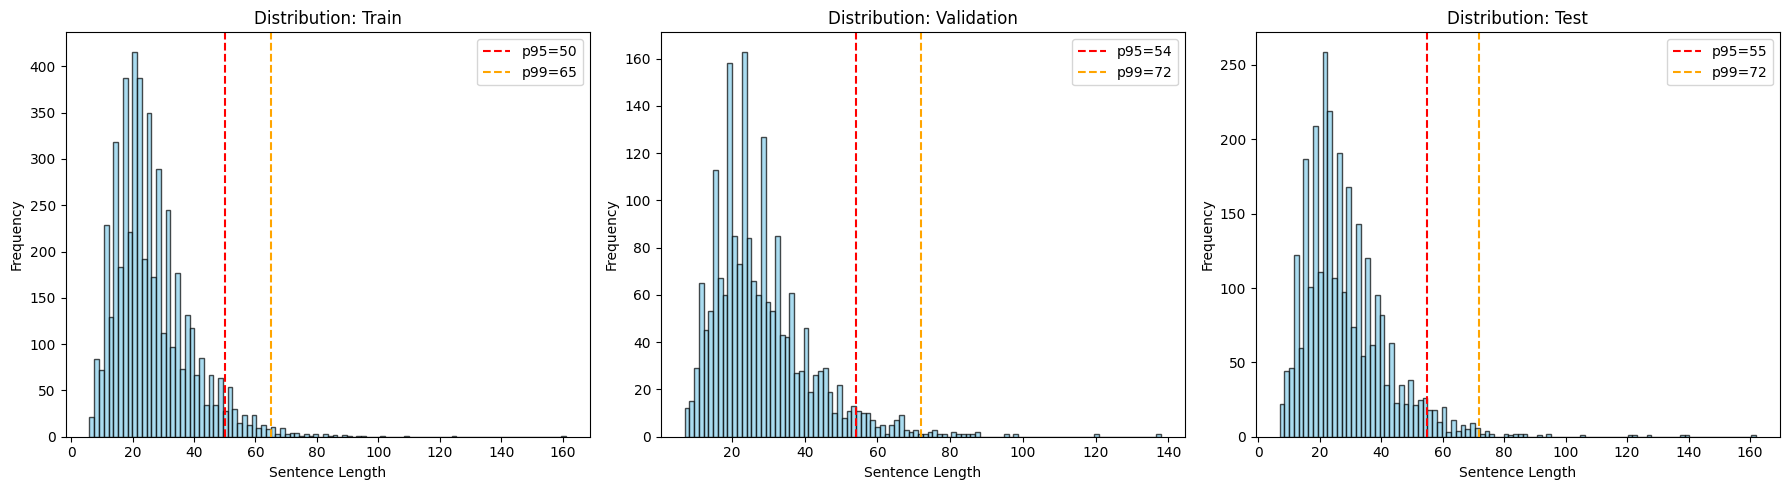

In [9]:
dataset_stats = {}
splits = ["train", "validation", "test"]

# Thiết lập figure cho plotting (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, split in enumerate(splits):
    # 1. Trích xuất độ dài
    lengths = np.array(length_dataset[split]["length"])

    # 2. Tính toán các chỉ số
    p95 = int(np.percentile(lengths, 95))
    p99 = int(np.percentile(lengths, 99))
    max_val = int(lengths.max())
    mean_val = lengths.mean()

    # 3. Lưu vào dictionary
    dataset_stats[split] = {
        "p95": p95,
        "p99": p99,
        "max_len": max_val,
        "mean": mean_val
    }

    # 4. In thông tin ra màn hình
    print(f"--- Statistics for {split} ---")
    print(f"Mean: {mean_val:.2f} | Max: {max_val} | p95: {p95} | p99: {p99}\n")

    # 5. Vẽ biểu đồ histogram lên subplot tương ứng
    axes[i].hist(lengths, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(p95, color='red', linestyle='--', label=f'p95={p95}')
    axes[i].axvline(p99, color='orange', linestyle='--', label=f'p99={p99}')

    axes[i].set_title(f'Distribution: {split.capitalize()}')
    axes[i].set_xlabel('Sentence Length')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Tokenize dataset

In [10]:
unique_tags = set()
for tags in clean_dataset['train']['tags']:
    unique_tags.update(tags)

unique_tags = sorted(list(unique_tags))

label2idx = {tag: i for i, tag in enumerate(unique_tags)}
idx2label = {i: tag for i, tag in enumerate(unique_tags)}

IGNORE_INDEX = -100

print(f"Số lượng nhãn: {len(unique_tags)}")
print("IGNORE_INDEX:", IGNORE_INDEX)
print("label2idx:", label2idx)

Số lượng nhãn: 20
IGNORE_INDEX: -100
label2idx: {'B-AGE': 0, 'B-DATE': 1, 'B-GENDER': 2, 'B-JOB': 3, 'B-LOCATION': 4, 'B-NAME': 5, 'B-ORGANIZATION': 6, 'B-PATIENT_ID': 7, 'B-SYMPTOM_AND_DISEASE': 8, 'B-TRANSPORTATION': 9, 'I-AGE': 10, 'I-DATE': 11, 'I-JOB': 12, 'I-LOCATION': 13, 'I-NAME': 14, 'I-ORGANIZATION': 15, 'I-PATIENT_ID': 16, 'I-SYMPTOM_AND_DISEASE': 17, 'I-TRANSPORTATION': 18, 'O': 19}


In [11]:
# Do PhoBERT sử dụng kĩ thuật bpe do đó ta phải chỉnh lại label cho chính xác
def tokenize_and_align_labels(examples):
    all_input_ids = []
    all_labels = []
    all_attention_masks = []

    cls_token_id = tokenizer.cls_token_id   # PhoBERT: <s>
    sep_token_id = tokenizer.sep_token_id   # PhoBERT: </s>


    for words, tags in zip(examples["words"], examples["tags"]):

        body_input_ids = []
        body_label_ids = []

        for word, tag in zip(words, tags):
            word_piece_ids = tokenizer.encode(word, add_special_tokens=False)
            if len(word_piece_ids) == 0:
                unk_id = tokenizer.unk_token_id
                word_piece_ids = [unk_id]

            body_input_ids.extend(word_piece_ids)

            body_label_ids.append(label2idx[tag])

            if len(word_piece_ids) > 1:
                body_label_ids.extend([IGNORE_INDEX] * (len(word_piece_ids) - 1))

        input_ids = [cls_token_id] + body_input_ids + [sep_token_id]
        labels = [IGNORE_INDEX] + body_label_ids + [IGNORE_INDEX]
        attention_mask = [1] * len(input_ids)

        all_input_ids.append(input_ids)
        all_labels.append(labels)
        all_attention_masks.append(attention_mask)

    return {
        "input_ids": all_input_ids,
        "labels": all_labels,
        "attention_mask": all_attention_masks,
    }

tokenized_dataset = clean_dataset.map(
    tokenize_and_align_labels,
    num_proc=2,
    batched=True,
    remove_columns=['words', 'tags']
)

Map (num_proc=2):   0%|          | 0/5027 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/3000 [00:00<?, ? examples/s]

In [12]:
train_dataset = tokenized_dataset["train"]
eval_dataset = tokenized_dataset["validation"]
test_dataset = tokenized_dataset["test"]

# Utils

In [13]:
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=IGNORE_INDEX
)

In [14]:
# Sử dụng hàm này để tránh cho shape của train_loss, eval_loss lệch nhau dẫn tới
# vẽ biểu đồ không chính xác

def plot_loss_curves(history, title='Training and Validation Loss'):
    # Keep only full-epoch logs to align train/eval points cleanly.
    train_epoch_loss = {}
    eval_epoch_loss = {}

    for log in history:
        epoch = log.get('epoch')
        if epoch is None:
            continue

        epoch_float = float(epoch)
        epoch_int = int(round(epoch_float))

        if epoch_int < 1 or abs(epoch_float - epoch_int) > 1e-8:
            continue

        if 'loss' in log and 'eval_loss' not in log:
            train_epoch_loss[epoch_int] = log['loss']
        if 'eval_loss' in log:
            eval_epoch_loss[epoch_int] = log['eval_loss']

    epochs = sorted(set(train_epoch_loss.keys()) & set(eval_epoch_loss.keys()))
    train_loss = [train_epoch_loss[e] for e in epochs]
    eval_loss = [eval_epoch_loss[e] for e in epochs]

    if not epochs:
        raise ValueError('No aligned full-epoch train/eval loss points were found in trainer.state.log_history.')

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, 'b', label='Training loss')
    plt.plot(epochs, eval_loss, 'r', label='Validation loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [15]:
def labels_from_predictions(predictions, labels):
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [idx2label[p] for (p, l) in zip(prediction, label) if l != IGNORE_INDEX]
        for prediction, label in zip(predictions, labels)
    ]

    true_labels = [
        [idx2label[l] for (p, l) in zip(prediction, label) if l != IGNORE_INDEX]
        for prediction, label in zip(predictions, labels)
    ]

    return true_labels, true_predictions

In [16]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    true_labels, true_predictions = labels_from_predictions(predictions, labels)

    return {
        "f1": f1_score(true_labels, true_predictions),
    }

In [17]:
def evaluate_model(trainer, eval_dataset, split_name='test', model_name='rnn'):
    predictions, labels, metrics = trainer.predict(eval_dataset)
    true_labels, true_predictions = labels_from_predictions(predictions, labels)

    accuracy = accuracy_score(true_labels, true_predictions)
    precision = precision_score(true_labels, true_predictions)
    recall = recall_score(true_labels, true_predictions)
    f1 = f1_score(true_labels, true_predictions)

    print(f"Evaluation on {split_name} set using {model_name}")
    print("Classification Report:")
    print(classification_report(true_labels, true_predictions))

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# Model

## Model Definition: BiGRU + SwiGLU

In [18]:
# Import thêm thư viện cần thiết
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from transformers import Trainer, TrainingArguments
from safetensors.torch import save_file
from seqeval.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [19]:
# Định nghĩa SwiGLU block
class SwiGLUBlock(nn.Module):
    def __init__(self, input_dim, ffn_dim, dropout=0.1):
        super().__init__()

        # Tạo 2 nhánh: value và gate
        self.fc = nn.Linear(input_dim, ffn_dim * 2)

        # Chiếu về lại input_dim để giữ shape ổn định
        self.proj = nn.Linear(ffn_dim, input_dim)

        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(input_dim)

    def forward(self, x):
        residual = x

        x = self.fc(x)
        value, gate = x.chunk(2, dim=-1)

        # SwiGLU: value * SiLU(gate)
        x = value * F.silu(gate)

        x = self.proj(x)
        x = self.dropout(x)

        # residual connection + layer norm giúp train ổn định hơn
        x = self.norm(x + residual)

        return x

In [20]:
# Định nghĩa model BiGRU + SwiGLU
class BiGRUSwiGLUModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim,
        num_layers=1,
        dropout=0.1,
        ffn_dim=512,
        ignore_index=-100,
        bidirectional=True
    ):
        super().__init__()

        self.ignore_index = ignore_index
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding_dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        gru_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.swiglu = SwiGLUBlock(
            input_dim=gru_output_dim,
            ffn_dim=ffn_dim,
            dropout=dropout
        )

        self.classifier_dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(gru_output_dim, output_dim)

    def forward(self, input_ids, attention_mask=None, labels=None):
        # input_ids: [batch_size, seq_len]

        embedded = self.embedding(input_ids)
        embedded = self.embedding_dropout(embedded)

        # gru_output: [batch_size, seq_len, hidden_dim * num_directions]
        gru_output, _ = self.gru(embedded)

        # Xử lý hidden state bằng SwiGLU
        features = self.swiglu(gru_output)
        features = self.classifier_dropout(features)

        # logits: [batch_size, seq_len, output_dim]
        logits = self.classifier(features)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(ignore_index=self.ignore_index)

            loss = loss_fn(
                logits.contiguous().view(-1, logits.shape[-1]),
                labels.contiguous().view(-1)
            )

        return {
            "loss": loss,
            "logits": logits
        }

In [21]:
# Khởi tạo config và model
bigru_swiglu_config = {
    "vocab_size": tokenizer.vocab_size,
    "embedding_dim": 256,
    "hidden_dim": 256,
    "output_dim": len(unique_tags),
    "num_layers": 1,
    "dropout": 0.1,
    "ffn_dim": 512,
    "ignore_index": IGNORE_INDEX,
    "bidirectional": True
}

bigru_swiglu_model = BiGRUSwiGLUModel(**bigru_swiglu_config)

bigru_swiglu_model

BiGRUSwiGLUModel(
  (embedding): Embedding(64000, 256)
  (embedding_dropout): Dropout(p=0.1, inplace=False)
  (gru): GRU(256, 256, batch_first=True, bidirectional=True)
  (swiglu): SwiGLUBlock(
    (fc): Linear(in_features=512, out_features=1024, bias=True)
    (proj): Linear(in_features=512, out_features=512, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (classifier_dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_features=512, out_features=20, bias=True)
)

In [22]:
# Kiểm tra số tham số
total_params = sum(p.numel() for p in bigru_swiglu_model.parameters())
trainable_params = sum(p.numel() for p in bigru_swiglu_model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Under 30M params: {total_params < 30_000_000}")

Total parameters: 17,972,756
Trainable parameters: 17,972,756
Under 30M params: True


### Model summary

Vì model trả về output dạng dictionary (`loss`, `logits`), ta dùng một wrapper nhỏ để `summary()` chỉ nhận tensor `logits`.  
`summary()` cần chạy thử model một lần để biết shape của từng layer và số lượng tham số, nên ta tạo một input giả có dạng giống `input_ids`.

In [41]:
# Model summary
class SummaryWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, input_ids):
        outputs = self.model(input_ids=input_ids)
        return outputs["logits"]


device = next(bigru_swiglu_model.parameters()).device

dummy_input = torch.randint(
    low=0,
    high=tokenizer.vocab_size,
    size=(1, 10),
    dtype=torch.long,
    device=device
)

summary_model = SummaryWrapper(bigru_swiglu_model)

summary(
    summary_model,
    input_data=dummy_input
)

Layer (type:depth-idx)                   Output Shape              Param #
SummaryWrapper                           [1, 10, 20]               --
├─BiGRUSwiGLUModel: 1-1                  [1, 10, 20]               --
│    └─Embedding: 2-1                    [1, 10, 256]              16,384,000
│    └─Dropout: 2-2                      [1, 10, 256]              --
│    └─GRU: 2-3                          [1, 10, 512]              789,504
│    └─SwiGLUBlock: 2-4                  [1, 10, 512]              --
│    │    └─Linear: 3-1                  [1, 10, 1024]             525,312
│    │    └─Linear: 3-2                  [1, 10, 512]              262,656
│    │    └─Dropout: 3-3                 [1, 10, 512]              --
│    │    └─LayerNorm: 3-4               [1, 10, 512]              1,024
│    └─Dropout: 2-5                      [1, 10, 512]              --
│    └─Linear: 2-6                       [1, 10, 20]               10,260
Total params: 17,972,756
Trainable params: 17,972,756
N

## Training

In [24]:
# Tạo training arguments
training_args_kwargs = {
    "output_dir": "/content/bigru_swiglu_checkpoints",

    "num_train_epochs": 100,
    "learning_rate": 5e-4,
    "weight_decay": 0.01,
    "max_grad_norm": 1.0,
    "warmup_steps": 50,

    "per_device_train_batch_size": 512,
    "per_device_eval_batch_size": 512,

    "logging_strategy": "epoch",
    "save_strategy": "epoch",

    "save_total_limit": 3,
    "load_best_model_at_end": True,
    "metric_for_best_model": "eval_f1",
    "greater_is_better": True,

    "report_to": "none"
}

try:
    bigru_swiglu_training_args = TrainingArguments(
        **training_args_kwargs,
        eval_strategy="epoch"
    )
except TypeError:
    bigru_swiglu_training_args = TrainingArguments(
        **training_args_kwargs,
        evaluation_strategy="epoch"
    )

In [26]:
# Tạo trainer
bigru_swiglu_trainer = Trainer(
    model=bigru_swiglu_model,
    args=bigru_swiglu_training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [27]:
# Train model
bigru_swiglu_trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,3.204008,2.787524,0.011466
2,2.256347,1.589934,0.006796
3,1.179099,1.034626,0.008119
4,0.696085,0.619005,0.273904
5,0.449471,0.461198,0.500659
6,0.316852,0.359162,0.610865
7,0.237202,0.292102,0.673769
8,0.185877,0.250682,0.732098
9,0.149873,0.223435,0.764057
10,0.122905,0.197780,0.784792


TrainOutput(global_step=1000, training_loss=0.09835625426005572, metrics={'train_runtime': 532.6655, 'train_samples_per_second': 943.744, 'train_steps_per_second': 1.877, 'total_flos': 0.0, 'train_loss': 0.09835625426005572, 'epoch': 100.0})

## Evaluate

In [28]:
def evaluate_trainer_on_test(trainer, test_dataset, idx2label, ignore_index=-100):
    predictions_output = trainer.predict(test_dataset)

    logits = predictions_output.predictions
    labels = predictions_output.label_ids

    preds = logits.argmax(axis=-1)

    true_labels = []
    true_predictions = []

    for pred_seq, label_seq in zip(preds, labels):
        current_true_labels = []
        current_true_predictions = []

        for pred_id, label_id in zip(pred_seq, label_seq):
            if label_id != ignore_index:
                current_true_labels.append(idx2label[int(label_id)])
                current_true_predictions.append(idx2label[int(pred_id)])

        true_labels.append(current_true_labels)
        true_predictions.append(current_true_predictions)

    report = classification_report(true_labels, true_predictions)

    result = {
        "accuracy": accuracy_score(true_labels, true_predictions),
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
        "classification_report": report
    }

    print(report)
    print("Accuracy:", result["accuracy"])
    print("Precision:", result["precision"])
    print("Recall:", result["recall"])
    print("F1:", result["f1"])

    return result

In [29]:
# Chạy đánh giá trên tập test
bigru_swiglu_result = evaluate_trainer_on_test(
    trainer=bigru_swiglu_trainer,
    test_dataset=tokenized_dataset["test"],
    idx2label=idx2label,
    ignore_index=IGNORE_INDEX
)

                     precision    recall  f1-score   support

                AGE       0.93      0.95      0.94       582
               DATE       0.94      0.97      0.95      1654
             GENDER       0.93      0.95      0.94       462
                JOB       0.55      0.44      0.49       173
           LOCATION       0.84      0.87      0.85      4441
               NAME       0.88      0.78      0.83       318
       ORGANIZATION       0.70      0.73      0.71       771
         PATIENT_ID       0.94      0.96      0.95      2005
SYMPTOM_AND_DISEASE       0.77      0.74      0.75      1136
     TRANSPORTATION       0.88      0.82      0.85       193

          micro avg       0.86      0.87      0.87     11735
          macro avg       0.84      0.82      0.83     11735
       weighted avg       0.86      0.87      0.87     11735

Accuracy: 0.9596045659329115
Precision: 0.8605313888190428
Recall: 0.8749041329356625
F1: 0.8676582438941941


## Save model weight

In [30]:
# Hàm lưu loss curve
def save_loss_curve(trainer, save_path):
    train_epochs = []
    train_losses = []

    eval_epochs = []
    eval_losses = []

    for log in trainer.state.log_history:
        if "loss" in log and "epoch" in log:
            train_epochs.append(log["epoch"])
            train_losses.append(log["loss"])

        if "eval_loss" in log and "epoch" in log:
            eval_epochs.append(log["epoch"])
            eval_losses.append(log["eval_loss"])

    plt.figure(figsize=(8, 5))

    if len(train_losses) > 0:
        plt.plot(train_epochs, train_losses, label="Train loss")

    if len(eval_losses) > 0:
        plt.plot(eval_epochs, eval_losses, label="Validation loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("BiGRU + SwiGLU Loss Curve")
    plt.legend()
    plt.grid(True)

    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

In [31]:
# Tạo thư mục lưu
save_dir = "/content/bigru_swiglu_ner"
os.makedirs(save_dir, exist_ok=True)

print("Save directory:", save_dir)

Save directory: /content/bigru_swiglu_ner


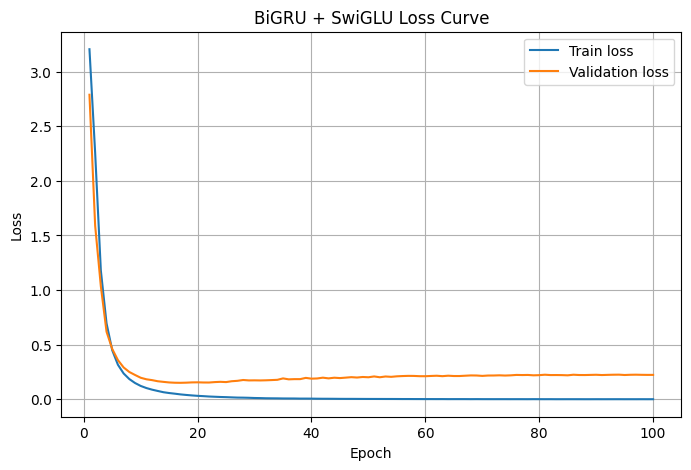

Saved: /content/bigru_swiglu_ner/loss_curve.png


In [32]:
# Lưu loss_curve
loss_curve_path = os.path.join(save_dir, "loss_curve.png")

save_loss_curve(
    trainer=bigru_swiglu_trainer,
    save_path=loss_curve_path
)

print("Saved:", loss_curve_path)

In [33]:
# Lưu model.safetensors
model_path = os.path.join(save_dir, "model.safetensors")

state_dict = {
    key: value.detach().cpu()
    for key, value in bigru_swiglu_trainer.model.state_dict().items()
}

save_file(state_dict, model_path)

print("Saved:", model_path)

Saved: /content/bigru_swiglu_ner/model.safetensors


In [34]:
# Lưu model_config.json
final_config = {
    "model_type": "BiGRU_SwiGLU",
    "vocab_size": int(tokenizer.vocab_size),
    "embedding_dim": 256,
    "hidden_dim": 256,
    "output_dim": int(len(unique_tags)),
    "num_layers": 1,
    "dropout": 0.1,
    "ffn_dim": 512,
    "ignore_index": int(IGNORE_INDEX),
    "bidirectional": True
}

final_config["total_params"] = int(
    sum(p.numel() for p in bigru_swiglu_trainer.model.parameters())
)

final_config["trainable_params"] = int(
    sum(p.numel() for p in bigru_swiglu_trainer.model.parameters() if p.requires_grad)
)

config_path = os.path.join(save_dir, "model_config.json")

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(final_config, f, ensure_ascii=False, indent=4)

print("Saved:", config_path)

Saved: /content/bigru_swiglu_ner/model_config.json


In [35]:
# Lưu result.json
result_path = os.path.join(save_dir, "result.json")

with open(result_path, "w", encoding="utf-8") as f:
    json.dump(bigru_swiglu_result, f, ensure_ascii=False, indent=4)

print("Saved:", result_path)

Saved: /content/bigru_swiglu_ner/result.json


In [36]:
print("Files in save_dir:")

for file_name in os.listdir(save_dir):
    print("-", file_name)

Files in save_dir:
- result.json
- model_config.json
- loss_curve.png
- model.safetensors


In [37]:
# Tóm tắt kết quả
print("Model: BiGRU + SwiGLU")
print(f"Total params: {final_config['total_params']:,}")
print(f"Trainable params: {final_config['trainable_params']:,}")
print(f"Accuracy: {bigru_swiglu_result['accuracy']:.4f}")
print(f"Precision: {bigru_swiglu_result['precision']:.4f}")
print(f"Recall: {bigru_swiglu_result['recall']:.4f}")
print(f"F1 score: {bigru_swiglu_result['f1']:.4f}")
print(f"F1 > 0.5: {bigru_swiglu_result['f1'] > 0.5}")
print(f"Params < 30M: {final_config['total_params'] < 30_000_000}")

Model: BiGRU + SwiGLU
Total params: 17,972,756
Trainable params: 17,972,756
Accuracy: 0.9596
Precision: 0.8605
Recall: 0.8749
F1 score: 0.8677
F1 > 0.5: True
Params < 30M: True


Tải về máy

In [44]:
!zip -r /content/bigru_swiglu_ner.zip /content/bigru_swiglu_ner

  adding: content/bigru_swiglu_ner/ (stored 0%)
  adding: content/bigru_swiglu_ner/result.json (deflated 63%)
  adding: content/bigru_swiglu_ner/model_config.json (deflated 42%)
  adding: content/bigru_swiglu_ner/loss_curve.png (deflated 10%)
  adding: content/bigru_swiglu_ner/model.safetensors (deflated 7%)


In [45]:
from google.colab import files

files.download("/content/bigru_swiglu_ner.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>